In [1]:
from pathlib import Path
import json
import datetime as dt
import importlib.metadata
import json
import math
import pickle
import textwrap
import warnings

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
from scipy.stats import wilcoxon
from sklearn.calibration import calibration_curve
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, balanced_accuracy_score, confusion_matrix, f1_score, precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 200)


def resolve_project_root():
    start = Path.cwd().resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists():
            return candidate
    return start


project_root = resolve_project_root()
data_dir = project_root / "data"
metadata_dir = data_dir / "metadata"
processed_dir = data_dir / "processed"
models_dir = project_root / "models"
reports_dir = project_root / "reports"
tables_dir = reports_dir / "tables"
figures_dir = reports_dir / "figures"

for folder in [processed_dir, models_dir, reports_dir, tables_dir, figures_dir, metadata_dir]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Project root: {project_root}")


Project root: /home/hamza/Documents/research/aero-res/aircraft_fault_localization


In [2]:
def safe_read_table(path):
    path = Path(path)
    if path.exists():
        if path.suffix == ".parquet":
            return pd.read_parquet(path)
        if path.suffix == ".csv":
            return pd.read_csv(path)
    parquet_path = path.with_suffix(".parquet")
    csv_path = path.with_suffix(".csv")
    if parquet_path.exists():
        return pd.read_parquet(parquet_path)
    if csv_path.exists():
        return pd.read_csv(csv_path)
    preview_csv = path.with_name(path.stem + "_preview.csv")
    if preview_csv.exists():
        return pd.read_csv(preview_csv)
    raise FileNotFoundError(f"Could not locate {path}, {parquet_path}, or {csv_path}")


def safe_to_parquet(frame, path):
    try:
        frame.to_parquet(path, index=False)
        return str(path)
    except Exception:
        fallback = path.with_suffix(".csv")
        frame.to_csv(fallback, index=False)
        return str(fallback)


standardized_path = processed_dir / "flight_rows_standardized.parquet"
anomaly_scores_path = processed_dir / "anomaly_model_scores.parquet"
anomaly_bundle_path = models_dir / "anomaly_detection_bundle.pkl"
feature_manifest_path = metadata_dir / "feature_manifest.csv"

missing_inputs = [str(path) for path in [anomaly_bundle_path, feature_manifest_path] if not path.exists()]
if missing_inputs:
    raise FileNotFoundError("Run the updated anomaly detection notebook first. Missing: " + ", ".join(missing_inputs))

standardized_df = safe_read_table(standardized_path)
anomaly_df = safe_read_table(anomaly_scores_path)
feature_manifest = pd.read_csv(feature_manifest_path)
with open(anomaly_bundle_path, "rb") as handle:
    anomaly_bundle = pickle.load(handle)

merge_keys = [column for column in ["file_name", "relative_path", "group", "sheet_name", "sequence_index", "original_row_index"] if column in standardized_df.columns and column in anomaly_df.columns]
if merge_keys:
    score_columns = [column for column in anomaly_df.columns if column not in standardized_df.columns or column in ["ensemble_anomaly_score", "anomaly_flag", "pca_reconstruction_error", "isolation_anomaly_score", "mahalanobis_pca_score"]]
    working_df = standardized_df.merge(anomaly_df[merge_keys + [column for column in score_columns if column not in merge_keys]], on=merge_keys, how="left")
else:
    working_df = anomaly_df.copy()

if "ensemble_anomaly_score" not in working_df.columns:
    raise ValueError("The anomaly score column is missing. Run notebook 01 again.")

selected_threshold = float(anomaly_bundle.get("selected_threshold", working_df["ensemble_anomaly_score"].quantile(0.99)))
high_threshold = float(max(selected_threshold, working_df["ensemble_anomaly_score"].quantile(0.995)))
working_df = working_df.sort_values(["file_name", "sequence_index"]).reset_index(drop=True)
print(f"Loaded rows: {len(working_df):,}")
print(f"Loaded files: {working_df['file_name'].nunique():,}")


Loaded rows: 524,149
Loaded files: 36


In [3]:
def detect_fault_onset(file_frame, selected_threshold, high_threshold):
    frame = file_frame.sort_values("sequence_index").reset_index(drop=True)
    scores = pd.to_numeric(frame["ensemble_anomaly_score"], errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(method="ffill").fillna(method="bfill").fillna(0).to_numpy()
    n_rows = len(scores)
    if n_rows == 0:
        return {"onset_position": 0, "onset_sequence_index": 0, "method": "empty", "confidence": "low", "pre_onset_median": np.nan, "post_onset_median": np.nan}
    min_start = int(np.clip(n_rows * 0.10, 10, max(10, n_rows - 1)))
    window = int(np.clip(n_rows * 0.035, 7, 75))
    sustain = int(np.clip(n_rows * 0.012, 4, 18))
    rolling_median = pd.Series(scores).rolling(window=window, min_periods=max(3, window // 3)).median().to_numpy()
    rolling_mean = pd.Series(scores).rolling(window=window, min_periods=max(3, window // 3)).mean().to_numpy()
    primary_flags = (rolling_median >= selected_threshold) & (np.arange(n_rows) >= min_start)
    sustained = pd.Series(primary_flags.astype(int)).rolling(window=sustain, min_periods=sustain).sum().ge(sustain).to_numpy()
    positions = np.flatnonzero(sustained)
    method = "sustained_threshold_crossing"
    if len(positions):
        position = int(max(min_start, positions[0] - sustain + 1))
    else:
        high_positions = np.flatnonzero((scores >= high_threshold) & (np.arange(n_rows) >= min_start))
        if len(high_positions):
            position = int(high_positions[0])
            method = "high_confidence_single_crossing"
        else:
            smooth = pd.Series(rolling_mean).fillna(method="bfill").fillna(method="ffill").fillna(0).to_numpy()
            gradient = np.gradient(smooth)
            search = gradient[min_start:] if min_start < len(gradient) else gradient
            position = int(min_start + np.nanargmax(search)) if len(search) else int(np.nanargmax(scores))
            method = "largest_smoothed_score_increase"
    position = int(np.clip(position, 0, n_rows - 1))
    pre_scores = scores[: max(position, 1)]
    post_scores = scores[position:]
    pre_median = float(np.nanmedian(pre_scores)) if len(pre_scores) else np.nan
    post_median = float(np.nanmedian(post_scores)) if len(post_scores) else np.nan
    difference = post_median - pre_median
    if method == "sustained_threshold_crossing" and difference > 0:
        confidence = "medium"
    elif method == "high_confidence_single_crossing" and difference > 0:
        confidence = "medium_low"
    else:
        confidence = "low"
    return {"onset_position": position, "onset_sequence_index": int(frame.loc[position, "sequence_index"]), "method": method, "confidence": confidence, "pre_onset_median": pre_median, "post_onset_median": post_median}


onset_rows = []
for file_name, file_frame in working_df.loc[working_df["group"].eq("defective")].groupby("file_name", sort=True):
    result = detect_fault_onset(file_frame, selected_threshold, high_threshold)
    result.update({"file_name": file_name, "group": "defective", "rows": int(len(file_frame))})
    onset_rows.append(result)

fault_onset_reference = pd.DataFrame(onset_rows)
if len(fault_onset_reference):
    fault_onset_reference["prefault_window_rows"] = fault_onset_reference["rows"].apply(lambda value: int(np.clip(value * 0.20, 40, 350)))
    fault_onset_reference["prefault_start_position"] = (fault_onset_reference["onset_position"] - fault_onset_reference["prefault_window_rows"]).clip(lower=0).astype("int64")
else:
    fault_onset_reference = pd.DataFrame(columns=["file_name", "group", "rows", "onset_position", "onset_sequence_index", "method", "confidence", "pre_onset_median", "post_onset_median", "prefault_window_rows", "prefault_start_position"])

fault_onset_reference.to_csv(processed_dir / "fault_onset_reference.csv", index=False)
fault_onset_reference.to_csv(tables_dir / "fault_onset_reference.csv", index=False)
display(fault_onset_reference)


,onset_position,onset_sequence_index,method,confidence,pre_onset_median,post_onset_median,file_name,group,rows,prefault_window_rows,prefault_start_position
0,1939,1939,sustained_threshold_crossing,low,1.501919,0.719712,Defect15(01).xlsx,defective,12431,350,1589
1,1698,1698,sustained_threshold_crossing,low,1.625264,1.348887,Defect15(02).xlsx,defective,4902,350,1348
2,15639,15639,sustained_threshold_crossing,medium,0.080623,2.001061,Defect15(03).xlsx,defective,15689,350,15289
3,1312,1312,sustained_threshold_crossing,low,1.906026,0.298868,Defect15(04).xlsx,defective,13123,350,962
4,1435,1435,sustained_threshold_crossing,low,1.603427,0.709145,Defect16(01).xlsx,defective,9690,350,1085
5,1587,1587,sustained_threshold_crossing,low,1.177343,0.232218,Defect16(02).xlsx,defective,14537,350,1237
6,14661,14661,sustained_threshold_crossing,medium,0.011067,1.944658,Defect16(03).xlsx,defective,14683,350,14311
7,1939,1939,sustained_threshold_crossing,low,1.501919,0.719712,Defected 1.xlsx,defective,12431,350,1589
8,1698,1698,sustained_threshold_crossing,low,1.625264,1.348887,Defected 2.xlsx,defective,4902,350,1348
9,15639,15639,sustained_threshold_crossing,medium,0.080623,2.001061,Defected 3.xlsx,defective,15689,350,15289


In [4]:
onset_lookup = fault_onset_reference.set_index("file_name").to_dict("index") if len(fault_onset_reference) else {}
labeled_parts = []

for file_name, file_frame in working_df.groupby("file_name", sort=False):
    frame = file_frame.sort_values("sequence_index").reset_index(drop=True).copy()
    frame["row_position_in_file"] = np.arange(len(frame), dtype=np.int64)
    frame["target_label"] = "normal"
    frame["target_binary"] = 0
    frame["fault_onset_position"] = np.nan
    frame["prefault_start_position"] = np.nan
    frame["rows_to_onset"] = np.nan
    if frame["group"].iloc[0] == "defective" and file_name in onset_lookup:
        onset_position = int(onset_lookup[file_name]["onset_position"])
        prefault_start = int(onset_lookup[file_name]["prefault_start_position"])
        frame["fault_onset_position"] = onset_position
        frame["prefault_start_position"] = prefault_start
        frame["rows_to_onset"] = onset_position - frame["row_position_in_file"]
        prefault_mask = frame["row_position_in_file"].ge(prefault_start) & frame["row_position_in_file"].lt(onset_position)
        post_onset_mask = frame["row_position_in_file"].ge(onset_position)
        frame.loc[prefault_mask, "target_label"] = "pre_fault"
        frame.loc[post_onset_mask, "target_label"] = "fault_post_onset"
        frame.loc[prefault_mask, "target_binary"] = 1
    labeled_parts.append(frame)

labeled_df = pd.concat(labeled_parts, ignore_index=True)
labeled_df["training_eligible"] = labeled_df["target_label"].isin(["normal", "pre_fault"])
written_label_path = safe_to_parquet(labeled_df, processed_dir / "prefault_labeled_data.parquet")

target_summary = labeled_df.groupby(["group", "target_label"], as_index=False).agg(files=("file_name", "nunique"), rows=("target_label", "size"))
file_target_summary = labeled_df.groupby(["file_name", "group", "target_label"], as_index=False).size().rename(columns={"size": "rows"})
target_summary.to_csv(tables_dir / "target_summary.csv", index=False)
file_target_summary.to_csv(tables_dir / "file_target_summary.csv", index=False)
print(f"Saved labeled dataset: {written_label_path}")
display(target_summary)


Saved labeled dataset: /home/hamza/Documents/research/aero-res/aircraft_fault_localization/data/processed/prefault_labeled_data.parquet


,group,target_label,files,rows
0,defective,fault_post_onset,14,93568
1,defective,normal,14,71642
2,defective,pre_fault,14,4900
3,healthy,normal,22,354039


In [5]:
def choose_base_features(feature_manifest, labeled_df):
    manifest = feature_manifest.copy()
    if "selected_for_anomaly" in manifest.columns:
        manifest = manifest.loc[manifest["selected_for_anomaly"].astype(bool)].copy()
    sort_columns = [column for column in ["median_non_null_ratio", "healthy_file_ratio", "defective_file_ratio", "median_unique_values"] if column in manifest.columns]
    if sort_columns:
        manifest = manifest.sort_values(sort_columns, ascending=False)
    blocked = {
        "pca_reconstruction_error",
        "isolation_anomaly_score",
        "mahalanobis_pca_score",
        "pca_reconstruction_error_robust_z",
        "isolation_anomaly_score_robust_z",
        "mahalanobis_pca_score_robust_z",
        "ensemble_anomaly_score",
        "anomaly_flag",
    }
    features = [feature for feature in manifest["feature"].tolist() if feature in labeled_df.columns and feature not in blocked]
    return features[:45]


def rolling_slope(series, window):
    values = series.astype("float32")
    x = np.arange(window, dtype="float32")
    x = x - x.mean()
    denominator = float(np.sum(x * x))
    def compute(chunk):
        arr = np.asarray(chunk, dtype="float32")
        if len(arr) != window or np.isnan(arr).all() or denominator == 0:
            return np.nan
        filled = pd.Series(arr).fillna(method="ffill").fillna(method="bfill").fillna(0).to_numpy(dtype="float32")
        return float(np.sum((filled - filled.mean()) * x) / denominator)
    return values.rolling(window=window, min_periods=max(3, window // 2)).apply(compute, raw=True)


def add_temporal_features_for_file(file_frame, base_features, windows=(5, 20, 50)):
    frame = file_frame.sort_values("sequence_index").reset_index(drop=True)
    output_columns = ["file_name", "relative_path", "group", "sheet_name", "sequence_index", "original_row_index", "row_position_in_file", "target_label", "target_binary", "training_eligible", "fault_onset_position", "prefault_start_position", "rows_to_onset"]
    existing_output_columns = [column for column in output_columns if column in frame.columns]
    output = frame[existing_output_columns].copy()
    numeric = frame[base_features].apply(pd.to_numeric, errors="coerce").astype("float32")
    for feature in base_features:
        series = numeric[feature]
        output[f"current__{feature}"] = series.astype("float32")
        output[f"delta1__{feature}"] = series.diff().fillna(0).astype("float32")
        output[f"missing__{feature}"] = series.isna().astype("int8")
    for window in windows:
        rolled = numeric.rolling(window=window, min_periods=max(2, window // 3))
        means = rolled.mean().astype("float32")
        stds = rolled.std().fillna(0).astype("float32")
        for feature in base_features:
            output[f"mean{window}__{feature}"] = means[feature]
            if window <= 20:
                output[f"std{window}__{feature}"] = stds[feature]
            if window in (20, 50):
                output[f"slope{window}__{feature}"] = rolling_slope(numeric[feature], window).astype("float32")
    ewm = numeric.ewm(span=20, adjust=False, min_periods=3).mean().astype("float32")
    for feature in base_features:
        output[f"ewm20__{feature}"] = ewm[feature]
    output = output.replace([np.inf, -np.inf], np.nan)
    return output


base_features = choose_base_features(feature_manifest, labeled_df)
if len(base_features) < 2:
    raise ValueError("Too few base features are available for prediction.")

temporal_parts = []
for file_name, file_frame in labeled_df.groupby("file_name", sort=False):
    temporal_parts.append(add_temporal_features_for_file(file_frame, base_features))

temporal_df = pd.concat(temporal_parts, ignore_index=True)
float_columns = temporal_df.select_dtypes(include=["float64", "float32"]).columns.tolist()
temporal_df[float_columns] = temporal_df[float_columns].astype("float32")
written_temporal_path = safe_to_parquet(temporal_df, processed_dir / "temporal_trend_feature_dataset.parquet")
feature_columns = [column for column in temporal_df.columns if "__" in column]

feature_inventory = pd.DataFrame({"feature_name": feature_columns, "base_feature_count": len(base_features)})
feature_inventory.to_csv(tables_dir / "temporal_feature_inventory.csv", index=False)
training_summary = pd.DataFrame({"metric": ["rows", "files", "base_features", "temporal_features"], "value": [len(temporal_df), temporal_df["file_name"].nunique(), len(base_features), len(feature_columns)]})
training_summary.to_csv(tables_dir / "temporal_training_summary.csv", index=False)
print(f"Saved temporal dataset: {written_temporal_path}")
display(training_summary)


Saved temporal dataset: /home/hamza/Documents/research/aero-res/aircraft_fault_localization/data/processed/temporal_trend_feature_dataset.parquet


,metric,value
0,rows,524149
1,files,36
2,base_features,45
3,temporal_features,495


In [6]:
def sample_training_rows(frame, random_state, max_normal_per_file=3500, max_positive_per_file=3500):
    sampled = []
    generator = np.random.default_rng(random_state)
    for file_name, file_frame in frame.groupby("file_name", sort=False):
        positives = file_frame.loc[file_frame["target_binary"].eq(1)]
        negatives = file_frame.loc[file_frame["target_binary"].eq(0)]
        if len(positives) > max_positive_per_file:
            positives = positives.sample(max_positive_per_file, random_state=int(generator.integers(0, 1_000_000)))
        if len(negatives) > max_normal_per_file:
            negatives = negatives.sample(max_normal_per_file, random_state=int(generator.integers(0, 1_000_000)))
        sampled.append(pd.concat([positives, negatives], ignore_index=False))
    output = pd.concat(sampled, ignore_index=False)
    return output.sample(frac=1.0, random_state=random_state)


def make_candidates(row_count, positive_rate):
    min_leaf = int(np.clip(row_count * 0.003, 8, 80))
    candidates = {
        "logistic_robust": Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", RobustScaler(quantile_range=(10, 90))),
                ("classifier", LogisticRegression(max_iter=1500, class_weight="balanced", solver="lbfgs", n_jobs=-1, random_state=RANDOM_STATE)),
            ]
        ),
        "random_forest": Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                ("classifier", RandomForestClassifier(n_estimators=320, max_depth=8, min_samples_leaf=min_leaf, max_features="sqrt", class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1)),
            ]
        ),
        "extra_trees": Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                ("classifier", ExtraTreesClassifier(n_estimators=360, max_depth=10, min_samples_leaf=min_leaf, max_features="sqrt", class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)),
            ]
        ),
        "hist_gradient_boosting": Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                ("classifier", HistGradientBoostingClassifier(max_iter=220, learning_rate=0.045, max_leaf_nodes=24, l2_regularization=0.15, random_state=RANDOM_STATE)),
            ]
        ),
    }
    try:
        from xgboost import XGBClassifier
        scale_pos_weight = float(max((1 - positive_rate) / max(positive_rate, 1e-6), 1.0))
        candidates["xgboost"] = Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                ("classifier", XGBClassifier(n_estimators=360, max_depth=4, learning_rate=0.035, subsample=0.85, colsample_bytree=0.80, reg_lambda=3.0, objective="binary:logistic", eval_metric="logloss", scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, n_jobs=-1)),
            ]
        )
    except Exception:
        pass
    try:
        from lightgbm import LGBMClassifier
        candidates["lightgbm"] = Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                ("classifier", LGBMClassifier(n_estimators=420, learning_rate=0.035, num_leaves=24, subsample=0.85, colsample_bytree=0.80, reg_lambda=3.0, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)),
            ]
        )
    except Exception:
        pass
    return candidates


def choose_group_splits(y, groups):
    group_table = pd.DataFrame({"group_id": groups, "target": y}).groupby("group_id", as_index=False).agg(target_max=("target", "max"))
    positive_groups = int(group_table["target_max"].sum())
    negative_groups = int(len(group_table) - positive_groups)
    n_splits = int(min(5, positive_groups, negative_groups, len(group_table)))
    if n_splits >= 2:
        try:
            splitter = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
            return list(splitter.split(np.zeros(len(y)), y, groups))
        except Exception:
            splitter = GroupKFold(n_splits=n_splits)
            return list(splitter.split(np.zeros(len(y)), y, groups))
    splitter = GroupShuffleSplit(n_splits=3, test_size=0.30, random_state=RANDOM_STATE)
    return list(splitter.split(np.zeros(len(y)), y, groups))


def predict_score(model, x):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(x)[:, 1]
    if hasattr(model, "decision_function"):
        values = model.decision_function(x)
        values = np.asarray(values, dtype="float64")
        return (values - values.min()) / max(values.max() - values.min(), 1e-12)
    return model.predict(x).astype("float64")


def safe_metric(function, y_true, values, default=np.nan):
    try:
        if function in [roc_auc_score, average_precision_score] and len(np.unique(y_true)) < 2:
            return default
        return float(function(y_true, values))
    except Exception:
        return default


In [1]:
from pathlib import Path
import os
import warnings
import numpy as np
import pandas as pd

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

from sklearn.base import clone
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings("ignore", category=ConvergenceWarning)

if "RANDOM_STATE" not in globals():
    RANDOM_STATE = 42

if "project_root" not in globals():
    start = Path.cwd().resolve()
    project_root = start
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists():
            project_root = candidate
            break

if "data_dir" not in globals():
    data_dir = project_root / "data"

if "processed_dir" not in globals():
    processed_dir = data_dir / "processed"

if "reports_dir" not in globals():
    reports_dir = project_root / "reports"

if "tables_dir" not in globals():
    tables_dir = reports_dir / "tables"

processed_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

def read_existing_table(path):
    path = Path(path)
    if path.exists() and path.suffix == ".parquet":
        return pd.read_parquet(path)
    if path.exists() and path.suffix == ".csv":
        return pd.read_csv(path)
    parquet_path = path.with_suffix(".parquet")
    csv_path = path.with_suffix(".csv")
    if parquet_path.exists():
        return pd.read_parquet(parquet_path)
    if csv_path.exists():
        return pd.read_csv(csv_path)
    raise FileNotFoundError(str(path))

if "temporal_df" not in globals():
    temporal_path = processed_dir / "temporal_trend_feature_dataset.parquet"
    try:
        temporal_df = read_existing_table(temporal_path)
        print(f"Loaded temporal feature dataset from {temporal_path}")
    except Exception:
        raise NameError(
            "temporal_df is not available. Run the notebook from the beginning, especially the cell that creates temporal_trend_feature_dataset.parquet."
        )

if "feature_columns" not in globals():
    feature_columns = [column for column in temporal_df.columns if "__" in column]

if len(feature_columns) == 0:
    raise ValueError("No temporal feature columns were found. Run the temporal feature engineering cell again.")

def metric_value(metric_func, *args, **kwargs):
    try:
        y_true = args[0] if len(args) else None
        if metric_func in [roc_auc_score, average_precision_score] and y_true is not None:
            if len(np.unique(y_true)) < 2:
                return np.nan
        return float(metric_func(*args, **kwargs))
    except Exception:
        return np.nan

safe_metric = metric_value

def sample_training_rows(frame, random_state, max_normal_per_file=2500, max_positive_per_file=2500):
    sampled = []
    generator = np.random.default_rng(random_state)

    for file_name, file_frame in frame.groupby("file_name", sort=False):
        positives = file_frame.loc[file_frame["target_binary"].eq(1)]
        negatives = file_frame.loc[file_frame["target_binary"].eq(0)]

        if len(positives) > max_positive_per_file:
            positives = positives.sample(
                max_positive_per_file,
                random_state=int(generator.integers(0, 1_000_000)),
            )

        if len(negatives) > max_normal_per_file:
            negatives = negatives.sample(
                max_normal_per_file,
                random_state=int(generator.integers(0, 1_000_000)),
            )

        sampled.append(pd.concat([positives, negatives], ignore_index=False))

    output = pd.concat(sampled, ignore_index=False)
    return output.sample(frac=1.0, random_state=random_state)

def make_candidates(row_count, positive_rate):
    min_leaf = int(np.clip(row_count * 0.004, 10, 100))

    candidates = {
        "logistic_robust": Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", RobustScaler(quantile_range=(10, 90))),
                (
                    "classifier",
                    LogisticRegression(
                        max_iter=8000,
                        class_weight="balanced",
                        solver="lbfgs",
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
        "random_forest": Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                (
                    "classifier",
                    RandomForestClassifier(
                        n_estimators=220,
                        max_depth=8,
                        min_samples_leaf=min_leaf,
                        max_features="sqrt",
                        class_weight="balanced_subsample",
                        random_state=RANDOM_STATE,
                        n_jobs=1,
                    ),
                ),
            ]
        ),
        "extra_trees": Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                (
                    "classifier",
                    ExtraTreesClassifier(
                        n_estimators=240,
                        max_depth=10,
                        min_samples_leaf=min_leaf,
                        max_features="sqrt",
                        class_weight="balanced",
                        random_state=RANDOM_STATE,
                        n_jobs=1,
                    ),
                ),
            ]
        ),
        "hist_gradient_boosting": Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                (
                    "classifier",
                    HistGradientBoostingClassifier(
                        max_iter=180,
                        learning_rate=0.045,
                        max_leaf_nodes=24,
                        l2_regularization=0.15,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
    }

    return candidates

def choose_group_splits(y, groups):
    group_table = (
        pd.DataFrame({"group_id": groups, "target": y})
        .groupby("group_id", as_index=False)
        .agg(target_max=("target", "max"))
    )

    positive_groups = int(group_table["target_max"].sum())
    negative_groups = int(len(group_table) - positive_groups)
    n_splits = int(min(5, positive_groups, negative_groups, len(group_table)))

    if n_splits >= 2:
        try:
            splitter = StratifiedGroupKFold(
                n_splits=n_splits,
                shuffle=True,
                random_state=RANDOM_STATE,
            )
            return list(splitter.split(np.zeros(len(y)), y, groups))
        except Exception:
            splitter = GroupKFold(n_splits=n_splits)
            return list(splitter.split(np.zeros(len(y)), y, groups))

    splitter = GroupShuffleSplit(n_splits=3, test_size=0.30, random_state=RANDOM_STATE)
    return list(splitter.split(np.zeros(len(y)), y, groups))

def predict_score(model, x):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(x)[:, 1]

    if hasattr(model, "decision_function"):
        values = model.decision_function(x)
        values = np.asarray(values, dtype="float64")
        return (values - values.min()) / max(values.max() - values.min(), 1e-12)

    return model.predict(x).astype("float64")

required_columns = ["training_eligible", "target_label", "target_binary", "file_name"]
missing_columns = [column for column in required_columns if column not in temporal_df.columns]

if missing_columns:
    raise ValueError(f"temporal_df is missing required columns: {missing_columns}")

model_df = temporal_df.loc[temporal_df["training_eligible"].astype(bool)].copy()
model_df = model_df.loc[model_df["target_label"].isin(["normal", "pre_fault"])].copy()

if model_df["target_binary"].nunique() < 2:
    raise ValueError("The training set contains only one class after provisional onset labeling.")

sampled_df = sample_training_rows(model_df, RANDOM_STATE)
X_sample = sampled_df[feature_columns].astype("float32")
y_sample = sampled_df["target_binary"].astype("int8").to_numpy()
groups_sample = sampled_df["file_name"].astype(str).to_numpy()

positive_rate = float(np.mean(y_sample))
candidates = make_candidates(len(sampled_df), positive_rate)
splits = choose_group_splits(y_sample, groups_sample)

comparison_rows = []
oof_predictions = {}
fold_rows = []

for model_name, model in candidates.items():
    oof = np.full(len(sampled_df), np.nan, dtype="float64")

    for fold, (train_index, valid_index) in enumerate(splits, start=1):
        X_train = X_sample.iloc[train_index]
        y_train = y_sample[train_index]
        X_valid = X_sample.iloc[valid_index]
        y_valid = y_sample[valid_index]

        fold_info = {
            "model": model_name,
            "fold": fold,
            "rows": int(len(valid_index)),
            "files": int(pd.Series(groups_sample[valid_index]).nunique()),
        }

        if len(np.unique(y_train)) < 2 or len(np.unique(y_valid)) < 2:
            fold_info.update(
                {
                    "roc_auc": np.nan,
                    "average_precision": np.nan,
                    "error": "single_class_fold",
                }
            )
            fold_rows.append(fold_info)
            continue

        try:
            fitted = clone(model).fit(X_train, y_train)
            valid_score = predict_score(fitted, X_valid)
            oof[valid_index] = valid_score

            fold_info.update(
                {
                    "roc_auc": metric_value(roc_auc_score, y_valid, valid_score),
                    "average_precision": metric_value(average_precision_score, y_valid, valid_score),
                }
            )
            fold_rows.append(fold_info)

        except Exception as exc:
            fold_info.update(
                {
                    "roc_auc": np.nan,
                    "average_precision": np.nan,
                    "error": str(exc),
                }
            )
            fold_rows.append(fold_info)

    valid_mask = np.isfinite(oof)
    oof_predictions[model_name] = oof

    if valid_mask.sum() and len(np.unique(y_sample[valid_mask])) == 2:
        precision_curve, recall_curve, thresholds = precision_recall_curve(
            y_sample[valid_mask],
            oof[valid_mask],
        )

        if len(thresholds):
            f1_values = 2 * precision_curve[:-1] * recall_curve[:-1] / np.clip(
                precision_curve[:-1] + recall_curve[:-1],
                1e-12,
                None,
            )
            best_index = int(np.nanargmax(f1_values))
            selected_cv_threshold = float(thresholds[best_index])
        else:
            selected_cv_threshold = 0.5

        y_pred = (oof[valid_mask] >= selected_cv_threshold).astype(int)

        comparison_rows.append(
            {
                "model": model_name,
                "valid_rows": int(valid_mask.sum()),
                "roc_auc": metric_value(roc_auc_score, y_sample[valid_mask], oof[valid_mask]),
                "average_precision": metric_value(average_precision_score, y_sample[valid_mask], oof[valid_mask]),
                "precision": metric_value(precision_score, y_sample[valid_mask], y_pred, zero_division=0),
                "recall": metric_value(recall_score, y_sample[valid_mask], y_pred, zero_division=0),
                "f1": metric_value(f1_score, y_sample[valid_mask], y_pred, zero_division=0),
                "balanced_accuracy": metric_value(balanced_accuracy_score, y_sample[valid_mask], y_pred),
                "cv_threshold": selected_cv_threshold,
            }
        )

model_comparison = pd.DataFrame(comparison_rows)

if model_comparison.empty:
    fold_metrics = pd.DataFrame(fold_rows)
    fold_metrics.to_csv(tables_dir / "model_fold_metrics.csv", index=False)
    raise ValueError("No candidate model completed grouped validation.")

model_comparison = (
    model_comparison
    .sort_values(["average_precision", "f1", "roc_auc"], ascending=False)
    .reset_index(drop=True)
)

fold_metrics = pd.DataFrame(fold_rows)

model_comparison.to_csv(tables_dir / "model_comparison.csv", index=False)
fold_metrics.to_csv(tables_dir / "model_fold_metrics.csv", index=False)

best_model_name = str(model_comparison.iloc[0]["model"])
best_model = candidates[best_model_name]

print(f"Best model: {best_model_name}")
display(model_comparison)

Loaded temporal feature dataset from /home/hamza/Documents/research/aero-res/aircraft_fault_localization/data/processed/temporal_trend_feature_dataset.parquet
Best model: hist_gradient_boosting


,model,valid_rows,roc_auc,average_precision,precision,recall,f1,balanced_accuracy,cv_threshold
0,hist_gradient_boosting,82342,1.000000,0.999996,0.999796,0.999796,0.999796,0.999892,0.910266
1,random_forest,82342,0.999746,0.996409,0.983733,0.962653,0.973079,0.980823,0.911157
2,extra_trees,82342,0.999500,0.992417,0.945876,0.973673,0.959574,0.985074,0.838979
3,logistic_robust,82342,0.987595,0.763628,0.658133,0.965306,0.782659,0.966790,0.792753


In [4]:
from pathlib import Path
import os
import warnings
import numpy as np
import pandas as pd

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

def metric_value(metric_func, *args, **kwargs):
    try:
        y_true = args[0] if len(args) else None
        if metric_func in [roc_auc_score, average_precision_score] and y_true is not None:
            if len(np.unique(y_true)) < 2:
                return np.nan
        return float(metric_func(*args, **kwargs))
    except Exception:
        return np.nan

safe_metric = metric_value

def safe_to_parquet(frame, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    try:
        frame.to_parquet(path, index=False)
        return path
    except Exception:
        csv_path = path.with_suffix(".csv")
        frame.to_csv(csv_path, index=False)
        return csv_path

def force_serial_estimator(estimator):
    try:
        params = estimator.get_params(deep=True)
        serial_params = {}

        for key in params:
            if key == "n_jobs" or key.endswith("__n_jobs"):
                serial_params[key] = 1

        if serial_params:
            estimator.set_params(**serial_params)
    except Exception:
        pass

    return estimator

required_objects = [
    "best_model",
    "X_sample",
    "y_sample",
    "model_df",
    "feature_columns",
    "processed_dir",
    "tables_dir",
]

missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    raise NameError(
        "Missing required objects from previous cells: "
        + ", ".join(missing_objects)
        + ". Run the model-comparison cell successfully before running this block."
    )

processed_dir = Path(processed_dir)
tables_dir = Path(tables_dir)
processed_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

if "predict_score" not in globals():
    def predict_score(model, x):
        if hasattr(model, "predict_proba"):
            return model.predict_proba(x)[:, 1]

        if hasattr(model, "decision_function"):
            values = model.decision_function(x)
            values = np.asarray(values, dtype="float64")
            return (values - values.min()) / max(values.max() - values.min(), 1e-12)

        return model.predict(x).astype("float64")

if "sequence_index" not in model_df.columns:
    model_df = model_df.copy()
    model_df["sequence_index"] = model_df.groupby("file_name").cumcount()

if "group" not in model_df.columns:
    model_df = model_df.copy()
    model_df["group"] = np.where(
        model_df["target_binary"].astype(int).eq(1),
        "defective",
        "healthy",
    )

missing_feature_columns = [column for column in feature_columns if column not in model_df.columns]

if missing_feature_columns:
    raise ValueError(f"model_df is missing feature columns: {missing_feature_columns[:20]}")

final_model = clone(best_model)
final_model = force_serial_estimator(final_model)
final_model = final_model.fit(X_sample, y_sample)

full_training_frame = model_df.sort_values(["file_name", "sequence_index"]).copy()
X_full = full_training_frame[feature_columns].astype("float32")
y_full = full_training_frame["target_binary"].astype("int8").to_numpy()

full_scores_raw = predict_score(final_model, X_full)
full_scores_raw = np.asarray(full_scores_raw, dtype="float64")
full_scores_raw = np.nan_to_num(full_scores_raw, nan=0.0, posinf=1.0, neginf=0.0)

calibration_table = pd.DataFrame(
    columns=["mean_predicted_probability", "fraction_of_positives"]
)

try:
    if len(np.unique(y_full)) == 2 and len(np.unique(full_scores_raw)) > 1:
        prob_true, prob_pred = calibration_curve(
            y_full,
            full_scores_raw,
            n_bins=10,
            strategy="quantile",
        )
        calibration_table = pd.DataFrame(
            {
                "mean_predicted_probability": prob_pred,
                "fraction_of_positives": prob_true,
            }
        )
except Exception:
    pass

calibration_table.to_csv(tables_dir / "calibration_curve.csv", index=False)

full_training_frame["prediction_score"] = full_scores_raw.astype("float32")
full_training_frame["actual_binary"] = y_full.astype("int8")

quantile_thresholds = np.nanquantile(
    full_scores_raw,
    np.linspace(0.50, 0.995, 120),
)

threshold_candidates = np.unique(
    np.concatenate(
        [
            quantile_thresholds,
            np.linspace(0.05, 0.95, 19),
        ]
    )
)

threshold_candidates = threshold_candidates[np.isfinite(threshold_candidates)]

if len(threshold_candidates) == 0:
    threshold_candidates = np.array([0.5], dtype="float64")

threshold_rows = []

for threshold in threshold_candidates:
    y_pred = (full_scores_raw >= threshold).astype(int)

    temp = full_training_frame[["file_name", "group"]].copy()
    temp["prediction_score"] = full_scores_raw
    temp["predicted_binary"] = y_pred

    file_scores = (
        temp.groupby(["file_name", "group"], as_index=False)
        .agg(
            max_prediction_score=("prediction_score", "max"),
            mean_prediction_score=("prediction_score", "mean"),
            predicted_rows=("predicted_binary", "sum"),
            rows=("predicted_binary", "size"),
        )
    )

    file_scores["file_predicted_positive"] = (
        file_scores["max_prediction_score"].ge(threshold).astype(int)
    )

    if file_scores["group"].eq("healthy").any():
        healthy_file_false_alarm_rate = float(
            file_scores.loc[
                file_scores["group"].eq("healthy"),
                "file_predicted_positive",
            ].mean()
        )
    else:
        healthy_file_false_alarm_rate = np.nan

    if file_scores["group"].eq("defective").any():
        defective_file_detection_rate = float(
            file_scores.loc[
                file_scores["group"].eq("defective"),
                "file_predicted_positive",
            ].mean()
        )
    else:
        defective_file_detection_rate = np.nan

    f1_value = safe_metric(f1_score, y_full, y_pred, zero_division=0)

    threshold_rows.append(
        {
            "threshold": float(threshold),
            "precision": safe_metric(precision_score, y_full, y_pred, zero_division=0),
            "recall": safe_metric(recall_score, y_full, y_pred, zero_division=0),
            "f1": f1_value,
            "balanced_accuracy": safe_metric(balanced_accuracy_score, y_full, y_pred),
            "healthy_file_false_alarm_rate": healthy_file_false_alarm_rate,
            "defective_file_detection_rate": defective_file_detection_rate,
            "objective": f1_value
            + 0.15 * np.nan_to_num(defective_file_detection_rate)
            - 0.35 * np.nan_to_num(healthy_file_false_alarm_rate),
        }
    )

threshold_table = (
    pd.DataFrame(threshold_rows)
    .replace([np.inf, -np.inf], np.nan)
    .sort_values("objective", ascending=False)
    .reset_index(drop=True)
)

if threshold_table.empty:
    raise ValueError("Threshold search produced no valid threshold rows.")

selected_threshold = float(threshold_table.iloc[0]["threshold"])

full_training_frame["predicted_binary"] = (
    full_training_frame["prediction_score"].ge(selected_threshold).astype("int8")
)

prediction_path = safe_to_parquet(
    full_training_frame,
    processed_dir / "fault_prediction_scores.parquet",
)

threshold_table.to_csv(
    tables_dir / "prediction_threshold_search.csv",
    index=False,
)

print(f"Selected prediction threshold: {selected_threshold:.6f}")
print(f"Saved prediction scores: {prediction_path}")

display(threshold_table.head(15))

Selected prediction threshold: 0.600000
Saved prediction scores: /home/hamza/Documents/research/aero-res/aircraft_fault_localization/data/processed/fault_prediction_scores.parquet


,threshold,precision,recall,f1,balanced_accuracy,healthy_file_false_alarm_rate,defective_file_detection_rate,objective
0,0.60,0.997963,1.0,0.998981,0.999988,0.0,1.0,1.148981
1,0.65,0.997963,1.0,0.998981,0.999988,0.0,1.0,1.148981
2,0.70,0.997963,1.0,0.998981,0.999988,0.0,1.0,1.148981
3,0.75,0.997963,1.0,0.998981,0.999988,0.0,1.0,1.148981
4,0.80,0.997963,1.0,0.998981,0.999988,0.0,1.0,1.148981
5,0.05,0.997963,1.0,0.998981,0.999988,0.0,1.0,1.148981
6,0.25,0.997963,1.0,0.998981,0.999988,0.0,1.0,1.148981
7,0.85,0.997963,1.0,0.998981,0.999988,0.0,1.0,1.148981
8,0.95,0.997963,1.0,0.998981,0.999988,0.0,1.0,1.148981
9,0.90,0.997963,1.0,0.998981,0.999988,0.0,1.0,1.148981


In [6]:
from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

if "tables_dir" not in globals():
    if "reports_dir" in globals():
        tables_dir = Path(reports_dir) / "tables"
    elif "project_root" in globals():
        tables_dir = Path(project_root) / "reports" / "tables"
    else:
        tables_dir = Path.cwd() / "reports" / "tables"

tables_dir = Path(tables_dir)
tables_dir.mkdir(parents=True, exist_ok=True)

def metric_value(metric_func, *args, **kwargs):
    try:
        y_true = args[0] if len(args) else None
        if metric_func in [roc_auc_score, average_precision_score] and y_true is not None:
            if len(np.unique(y_true)) < 2:
                return np.nan
        return float(metric_func(*args, **kwargs))
    except Exception:
        return np.nan

safe_metric = metric_value

required_objects = ["full_training_frame", "y_full", "selected_threshold", "best_model_name"]

missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    raise NameError(
        "Missing required objects from previous cells: "
        + ", ".join(missing_objects)
        + ". Run the final model fitting and threshold-selection cell before running this block."
    )

full_training_frame = full_training_frame.copy()

if "prediction_score" not in full_training_frame.columns:
    raise ValueError("full_training_frame is missing prediction_score. Run the prediction scoring cell first.")

if "predicted_binary" not in full_training_frame.columns:
    full_training_frame["predicted_binary"] = (
        full_training_frame["prediction_score"].ge(selected_threshold).astype("int8")
    )

if "actual_binary" not in full_training_frame.columns:
    full_training_frame["actual_binary"] = np.asarray(y_full, dtype="int8")

if "file_name" not in full_training_frame.columns:
    raise ValueError("full_training_frame is missing file_name.")

if "group" not in full_training_frame.columns:
    full_training_frame["group"] = np.where(
        full_training_frame["actual_binary"].astype(int).eq(1),
        "defective",
        "healthy",
    )

y_full = np.asarray(y_full, dtype=int)
y_pred = full_training_frame["predicted_binary"].to_numpy(dtype=int)
prediction_scores = full_training_frame["prediction_score"].to_numpy(dtype="float64")

metrics_summary = pd.DataFrame(
    {
        "metric": [
            "model",
            "rows",
            "files",
            "roc_auc",
            "average_precision",
            "precision",
            "recall",
            "f1",
            "balanced_accuracy",
            "selected_threshold",
        ],
        "value": [
            best_model_name,
            int(len(full_training_frame)),
            int(full_training_frame["file_name"].nunique()),
            safe_metric(roc_auc_score, y_full, prediction_scores),
            safe_metric(average_precision_score, y_full, prediction_scores),
            safe_metric(precision_score, y_full, y_pred, zero_division=0),
            safe_metric(recall_score, y_full, y_pred, zero_division=0),
            safe_metric(f1_score, y_full, y_pred, zero_division=0),
            safe_metric(balanced_accuracy_score, y_full, y_pred),
            float(selected_threshold),
        ],
    }
)

file_prediction_scores = (
    full_training_frame.groupby(["file_name", "group"], as_index=False)
    .agg(
        rows=("prediction_score", "size"),
        max_prediction_score=("prediction_score", "max"),
        mean_prediction_score=("prediction_score", "mean"),
        predicted_rows=("predicted_binary", "sum"),
        actual_positive_rows=("actual_binary", "sum"),
    )
)

file_prediction_scores["predicted_positive_rate"] = (
    file_prediction_scores["predicted_rows"] / file_prediction_scores["rows"].clip(lower=1)
)

file_prediction_scores["file_predicted_positive"] = (
    file_prediction_scores["max_prediction_score"].ge(selected_threshold).astype(int)
)

if file_prediction_scores["group"].eq("healthy").any():
    healthy_file_false_alarm_rate = float(
        file_prediction_scores.loc[
            file_prediction_scores["group"].eq("healthy"),
            "file_predicted_positive",
        ].mean()
    )
else:
    healthy_file_false_alarm_rate = np.nan

if file_prediction_scores["group"].eq("defective").any():
    defective_file_detection_rate = float(
        file_prediction_scores.loc[
            file_prediction_scores["group"].eq("defective"),
            "file_predicted_positive",
        ].mean()
    )
else:
    defective_file_detection_rate = np.nan

extra_metrics = pd.DataFrame(
    {
        "metric": [
            "healthy_file_false_alarm_rate",
            "defective_file_detection_rate",
        ],
        "value": [
            healthy_file_false_alarm_rate,
            defective_file_detection_rate,
        ],
    }
)

metrics_summary = pd.concat([metrics_summary, extra_metrics], ignore_index=True)

metrics_summary.to_csv(tables_dir / "fault_prediction_metrics.csv", index=False)
file_prediction_scores.to_csv(tables_dir / "file_prediction_scores.csv", index=False)

confusion = confusion_matrix(y_full, y_pred, labels=[0, 1])

confusion_table = pd.DataFrame(
    confusion,
    index=["actual_normal", "actual_pre_fault"],
    columns=["predicted_normal", "predicted_pre_fault"],
)

confusion_table.to_csv(tables_dir / "prediction_confusion_matrix.csv")

display(metrics_summary)
display(file_prediction_scores.sort_values("max_prediction_score", ascending=False).head(25))

,metric,value
0,model,hist_gradient_boosting
1,rows,430581
2,files,36
3,roc_auc,1.0
4,average_precision,0.999997
5,precision,0.997963
6,recall,1.0
7,f1,0.998981
8,balanced_accuracy,0.999988
9,selected_threshold,0.6


,file_name,group,rows,max_prediction_score,mean_prediction_score,predicted_rows,actual_positive_rows,predicted_positive_rate,file_predicted_positive
23,Defected 5.xlsx,defective,1435,0.999677,0.243813,350,350,0.243902,1
16,Defect16(01).xlsx,defective,1435,0.999677,0.243813,350,350,0.243902,1
14,Defect15(03).xlsx,defective,15639,0.999676,0.022399,350,350,0.022380,1
18,Defect16(03).xlsx,defective,14661,0.999676,0.024226,355,350,0.024214,1
21,Defected 3.xlsx,defective,15639,0.999676,0.022399,350,350,0.022380,1
25,Defected 7.xlsx,defective,14661,0.999676,0.024226,355,350,0.024214,1
22,Defected 4.xlsx,defective,1312,0.999673,0.266706,350,350,0.266768,1
15,Defect15(04).xlsx,defective,1312,0.999673,0.266706,350,350,0.266768,1
13,Defect15(02).xlsx,defective,1698,0.999662,0.206070,350,350,0.206125,1
20,Defected 2.xlsx,defective,1698,0.999662,0.206070,350,350,0.206125,1


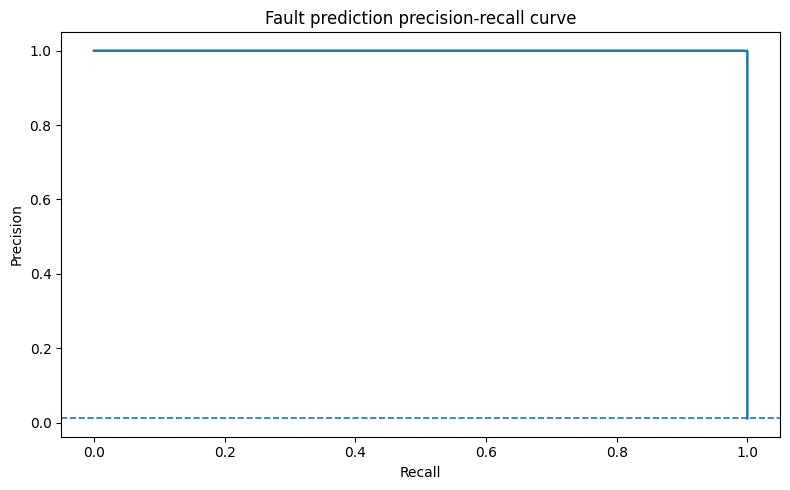

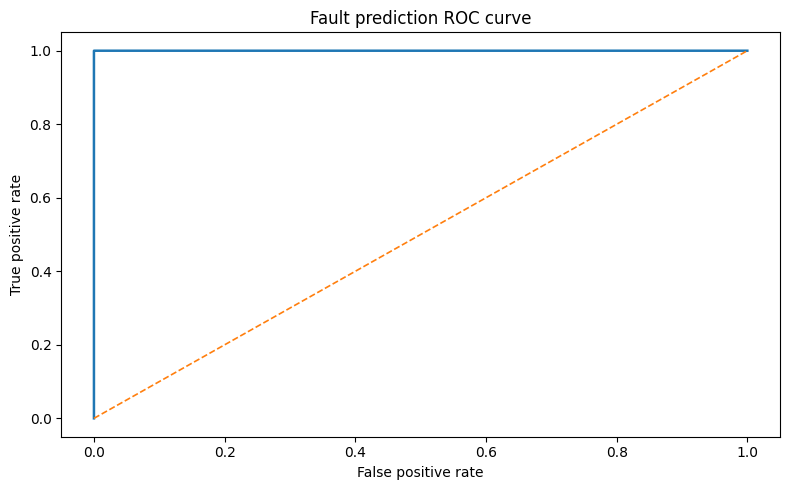

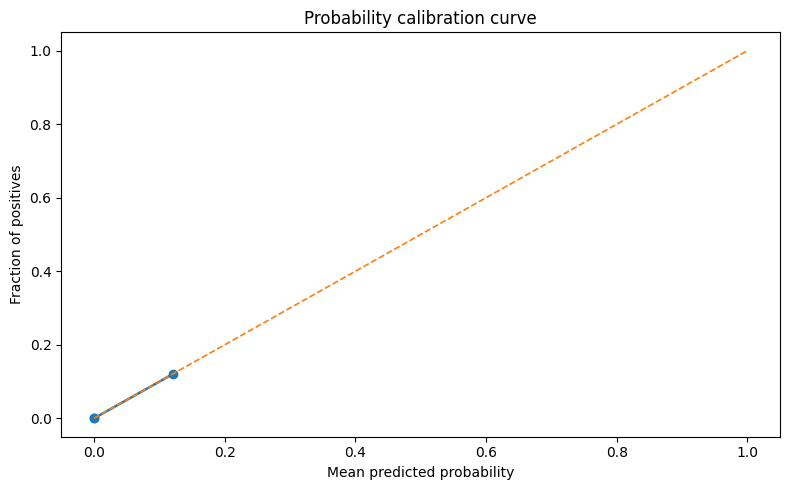

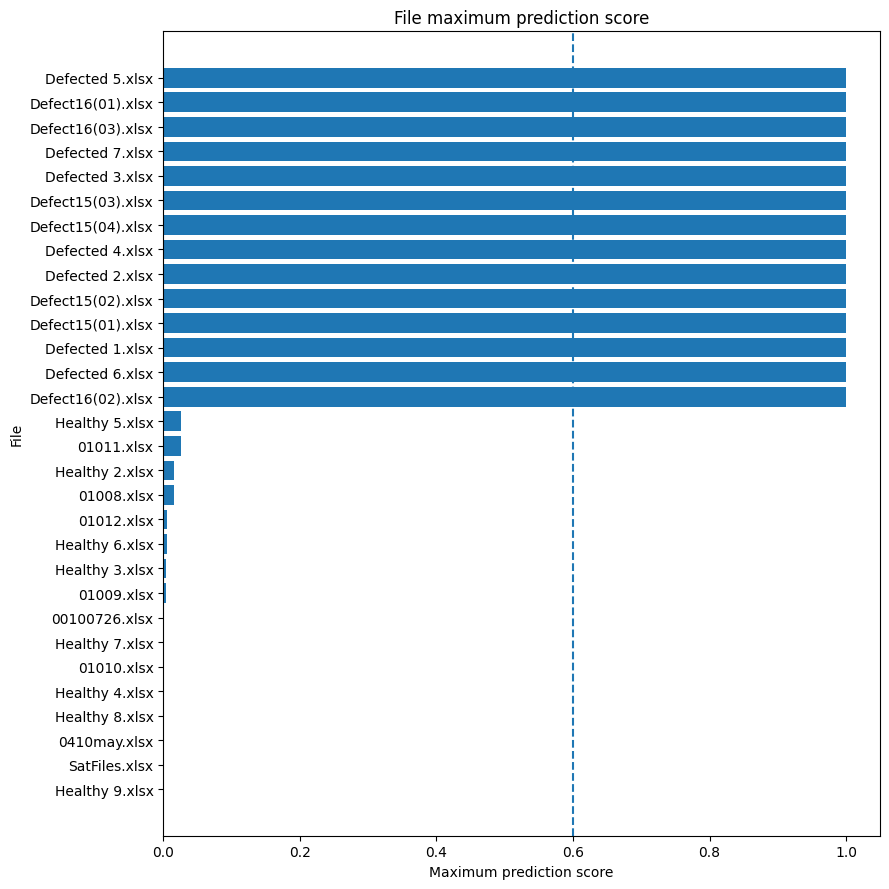

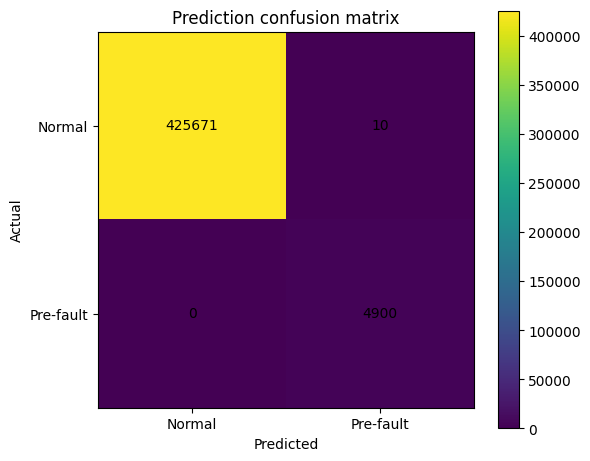

In [8]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
)

if "figures_dir" not in globals():
    if "reports_dir" in globals():
        figures_dir = Path(reports_dir) / "figures"
    elif "project_root" in globals():
        figures_dir = Path(project_root) / "reports" / "figures"
    else:
        figures_dir = Path.cwd() / "reports" / "figures"

figures_dir = Path(figures_dir)
figures_dir.mkdir(parents=True, exist_ok=True)

if "tables_dir" not in globals():
    if "reports_dir" in globals():
        tables_dir = Path(reports_dir) / "tables"
    elif "project_root" in globals():
        tables_dir = Path(project_root) / "reports" / "tables"
    else:
        tables_dir = Path.cwd() / "reports" / "tables"

tables_dir = Path(tables_dir)

required_objects = ["full_training_frame", "y_full", "selected_threshold"]

missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    raise NameError(
        "Missing required objects from previous cells: "
        + ", ".join(missing_objects)
        + ". Run the final model scoring and metrics cells before running this plotting block."
    )

full_training_frame = full_training_frame.copy()

if "prediction_score" not in full_training_frame.columns:
    raise ValueError("full_training_frame is missing prediction_score.")

if "predicted_binary" not in full_training_frame.columns:
    full_training_frame["predicted_binary"] = (
        full_training_frame["prediction_score"].ge(selected_threshold).astype("int8")
    )

if "actual_binary" not in full_training_frame.columns:
    full_training_frame["actual_binary"] = np.asarray(y_full, dtype="int8")

if "file_name" not in full_training_frame.columns:
    raise ValueError("full_training_frame is missing file_name.")

if "group" not in full_training_frame.columns:
    full_training_frame["group"] = np.where(
        full_training_frame["actual_binary"].astype(int).eq(1),
        "defective",
        "healthy",
    )

y_full = np.asarray(y_full, dtype=int)
y_pred = full_training_frame["predicted_binary"].to_numpy(dtype=int)
prediction_scores = full_training_frame["prediction_score"].to_numpy(dtype="float64")
prediction_scores = np.nan_to_num(prediction_scores, nan=0.0, posinf=1.0, neginf=0.0)

if "calibration_table" not in globals():
    calibration_path = tables_dir / "calibration_curve.csv"
    if calibration_path.exists():
        calibration_table = pd.read_csv(calibration_path)
    else:
        calibration_table = pd.DataFrame(
            columns=["mean_predicted_probability", "fraction_of_positives"]
        )

if "file_prediction_scores" not in globals():
    file_scores_path = tables_dir / "file_prediction_scores.csv"
    if file_scores_path.exists():
        file_prediction_scores = pd.read_csv(file_scores_path)
    else:
        file_prediction_scores = (
            full_training_frame.groupby(["file_name", "group"], as_index=False)
            .agg(
                rows=("prediction_score", "size"),
                max_prediction_score=("prediction_score", "max"),
                mean_prediction_score=("prediction_score", "mean"),
                predicted_rows=("predicted_binary", "sum"),
                actual_positive_rows=("actual_binary", "sum"),
            )
        )
        file_prediction_scores["predicted_positive_rate"] = (
            file_prediction_scores["predicted_rows"]
            / file_prediction_scores["rows"].clip(lower=1)
        )
        file_prediction_scores["file_predicted_positive"] = (
            file_prediction_scores["max_prediction_score"]
            .ge(selected_threshold)
            .astype(int)
        )

confusion = confusion_matrix(y_full, y_pred, labels=[0, 1])

def save_current_figure(path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

if len(np.unique(y_full)) == 2 and len(np.unique(prediction_scores)) > 1:
    precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
        y_full,
        prediction_scores,
    )

    plt.figure(figsize=(8, 5))
    plt.plot(recall_curve, precision_curve, linewidth=1.8)
    plt.axhline(float(np.mean(y_full)), linestyle="--", linewidth=1.2)
    plt.title("Fault prediction precision-recall curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    save_current_figure(figures_dir / "fault_prediction_precision_recall_curve.png")

    fpr, tpr, roc_thresholds = roc_curve(y_full, prediction_scores)

    plt.figure(figsize=(8, 5))
    plt.plot(fpr, tpr, linewidth=1.8)
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.2)
    plt.title("Fault prediction ROC curve")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    save_current_figure(figures_dir / "fault_prediction_roc_curve.png")

plt.figure(figsize=(8, 5))

if (
    len(calibration_table)
    and "mean_predicted_probability" in calibration_table.columns
    and "fraction_of_positives" in calibration_table.columns
):
    plt.plot(
        calibration_table["mean_predicted_probability"],
        calibration_table["fraction_of_positives"],
        marker="o",
        linewidth=1.8,
    )

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.2)
plt.title("Probability calibration curve")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
save_current_figure(figures_dir / "calibration_curve.png")

if len(file_prediction_scores):
    plot_file_scores = (
        file_prediction_scores
        .sort_values("max_prediction_score", ascending=True)
        .tail(30)
    )

    plt.figure(figsize=(9, max(5, 0.30 * len(plot_file_scores))))
    plt.barh(
        plot_file_scores["file_name"].astype(str),
        plot_file_scores["max_prediction_score"],
    )
    plt.axvline(selected_threshold, linestyle="--", linewidth=1.5)
    plt.title("File maximum prediction score")
    plt.xlabel("Maximum prediction score")
    plt.ylabel("File")
    save_current_figure(figures_dir / "file_level_prediction_scores.png")

plt.figure(figsize=(6, 5))
plt.imshow(confusion)

for i in range(confusion.shape[0]):
    for j in range(confusion.shape[1]):
        plt.text(j, i, str(int(confusion[i, j])), ha="center", va="center")

plt.xticks([0, 1], ["Normal", "Pre-fault"])
plt.yticks([0, 1], ["Normal", "Pre-fault"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Prediction confusion matrix")
plt.colorbar()
save_current_figure(figures_dir / "prediction_confusion_matrix.png")

In [9]:
def get_classifier_from_pipeline(model):
    if hasattr(model, "named_steps") and "classifier" in model.named_steps:
        return model.named_steps["classifier"]
    return model


classifier = get_classifier_from_pipeline(final_model)
importance_rows = []
if hasattr(classifier, "feature_importances_"):
    importance_rows = [{"feature": feature, "importance": float(value)} for feature, value in zip(feature_columns, classifier.feature_importances_)]
elif hasattr(classifier, "coef_"):
    coefficients = np.ravel(classifier.coef_)
    importance_rows = [{"feature": feature, "importance": float(abs(value))} for feature, value in zip(feature_columns, coefficients)]
feature_importance = pd.DataFrame(importance_rows).sort_values("importance", ascending=False) if importance_rows else pd.DataFrame(columns=["feature", "importance"])
feature_importance.to_csv(tables_dir / "feature_importance.csv", index=False)

if len(feature_importance):
    plot_importance = feature_importance.head(30).sort_values("importance", ascending=True)
    plt.figure(figsize=(9, max(5, 0.30 * len(plot_importance))))
    plt.barh(plot_importance["feature"], plot_importance["importance"])
    plt.title("Top predictive features")
    plt.xlabel("Model importance")
    plt.ylabel("Feature")
    save_current_figure(figures_dir / "top_predictive_features.png")

permutation_table = pd.DataFrame(columns=["feature", "importance_mean", "importance_std"])
try:
    validation_sample = full_training_frame.sample(min(len(full_training_frame), 6000), random_state=RANDOM_STATE)
    X_perm = validation_sample[feature_columns].astype("float32")
    y_perm = validation_sample["actual_binary"].astype(int).to_numpy()
    if len(np.unique(y_perm)) == 2:
        permutation = permutation_importance(final_model, X_perm, y_perm, scoring="average_precision", n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
        permutation_table = pd.DataFrame({"feature": feature_columns, "importance_mean": permutation.importances_mean, "importance_std": permutation.importances_std}).sort_values("importance_mean", ascending=False)
except Exception:
    pass
permutation_table.to_csv(tables_dir / "permutation_importance.csv", index=False)

if len(permutation_table):
    plot_perm = permutation_table.head(25).sort_values("importance_mean", ascending=True)
    plt.figure(figsize=(9, max(5, 0.30 * len(plot_perm))))
    plt.barh(plot_perm["feature"], plot_perm["importance_mean"], xerr=plot_perm["importance_std"])
    plt.title("Permutation importance")
    plt.xlabel("Average precision decrease")
    plt.ylabel("Feature")
    save_current_figure(figures_dir / "permutation_importance.png")


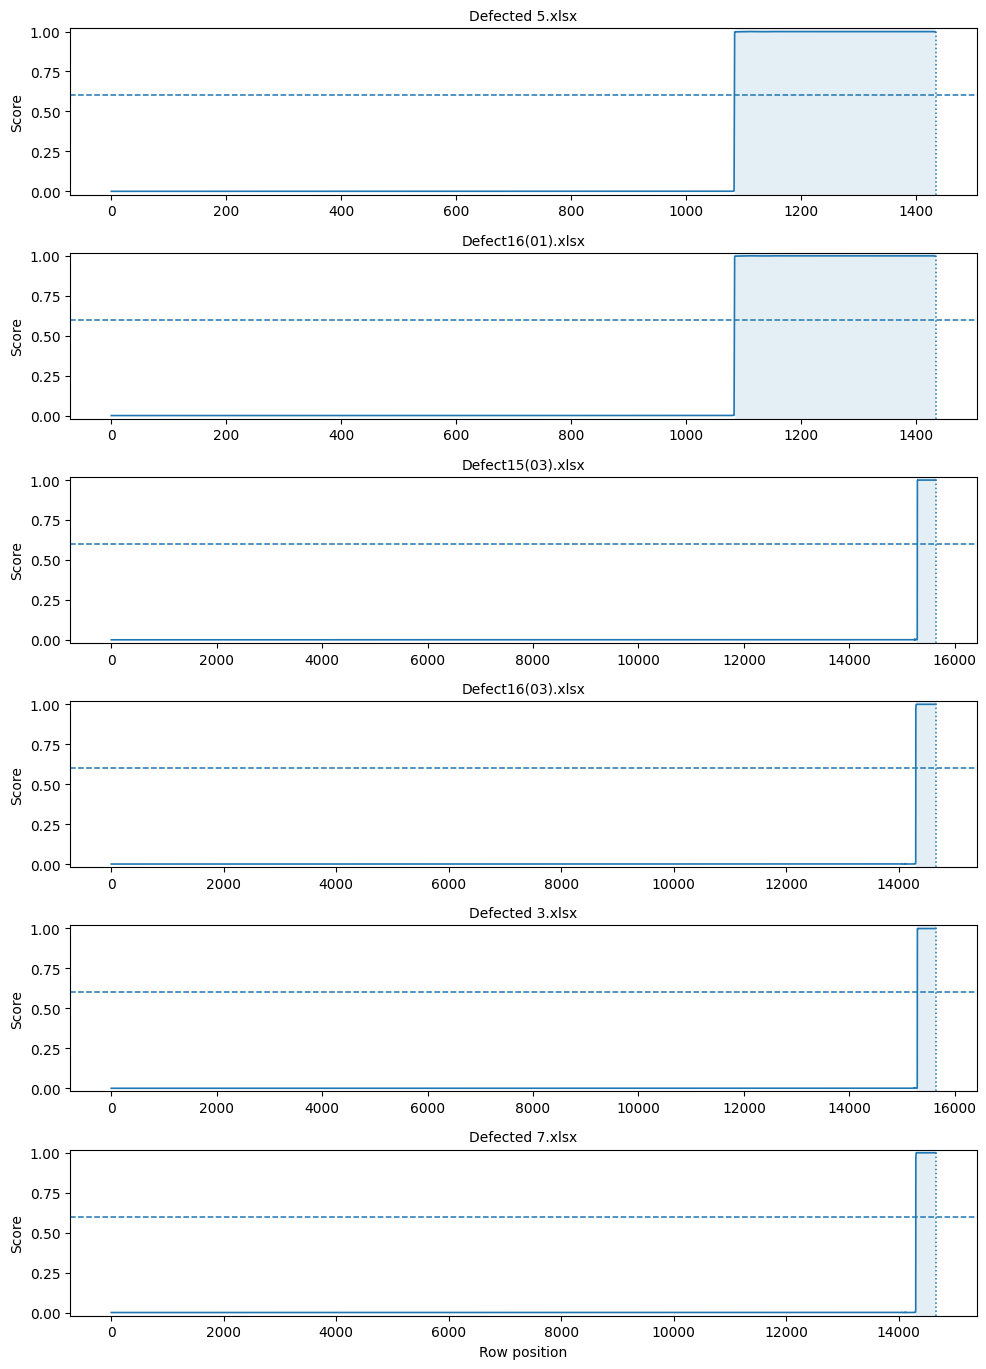

In [10]:
top_timeline_files = file_prediction_scores.sort_values("max_prediction_score", ascending=False).head(6)["file_name"].tolist()
if top_timeline_files:
    figure_height = max(4, 2.3 * len(top_timeline_files))
    plt.figure(figsize=(10, figure_height))
    for index, file_name in enumerate(top_timeline_files, start=1):
        file_frame = full_training_frame.loc[full_training_frame["file_name"].eq(file_name)].sort_values("row_position_in_file")
        plt.subplot(len(top_timeline_files), 1, index)
        plt.plot(file_frame["row_position_in_file"], file_frame["prediction_score"], linewidth=1.2)
        plt.axhline(selected_threshold, linestyle="--", linewidth=1.1)
        if file_frame["fault_onset_position"].notna().any():
            onset = float(file_frame["fault_onset_position"].dropna().iloc[0])
            prefault = float(file_frame["prefault_start_position"].dropna().iloc[0]) if file_frame["prefault_start_position"].notna().any() else np.nan
            plt.axvline(onset, linestyle=":", linewidth=1.1)
            if np.isfinite(prefault):
                plt.axvspan(prefault, onset, alpha=0.12)
        plt.ylim(-0.02, 1.02)
        plt.title(str(file_name), fontsize=10)
        plt.ylabel("Score")
        if index == len(top_timeline_files):
            plt.xlabel("Row position")
    save_current_figure(figures_dir / "prediction_timelines.png")


In [15]:
from pathlib import Path
import numpy as np
import pandas as pd

from scipy.stats import wilcoxon, binomtest

if "tables_dir" not in globals():
    if "reports_dir" in globals():
        tables_dir = Path(reports_dir) / "tables"
    elif "project_root" in globals():
        tables_dir = Path(project_root) / "reports" / "tables"
    else:
        tables_dir = Path.cwd() / "reports" / "tables"

tables_dir = Path(tables_dir)
tables_dir.mkdir(parents=True, exist_ok=True)

statistical_rows = []

if "model_comparison" not in globals():
    raise NameError("model_comparison is not available. Run the model comparison cell first.")

if "fold_metrics" not in globals():
    raise NameError("fold_metrics is not available. Run the model comparison cell first.")

if len(model_comparison) >= 2 and not fold_metrics.empty:
    candidate_model = str(model_comparison.iloc[0]["model"])
    baseline_model = str(model_comparison.iloc[1]["model"])

    merged_folds = (
        fold_metrics.loc[
            fold_metrics["model"].isin([candidate_model, baseline_model])
        ]
        .pivot_table(
            index="fold",
            columns="model",
            values="average_precision",
            aggfunc="mean",
        )
    )

    if candidate_model in merged_folds.columns and baseline_model in merged_folds.columns:
        paired = merged_folds[[candidate_model, baseline_model]].dropna()

        if len(paired) >= 2:
            try:
                if np.allclose(
                    paired[candidate_model].to_numpy(dtype=float),
                    paired[baseline_model].to_numpy(dtype=float),
                    equal_nan=True,
                ):
                    statistic = 0.0
                    p_value = 1.0
                else:
                    statistic, p_value = wilcoxon(
                        paired[candidate_model],
                        paired[baseline_model],
                        zero_method="wilcox",
                        alternative="two-sided",
                    )

                statistical_rows.append(
                    {
                        "test": "wilcoxon_fold_average_precision",
                        "candidate": candidate_model,
                        "baseline": baseline_model,
                        "statistic": float(statistic),
                        "p_value": float(p_value),
                        "paired_folds": int(len(paired)),
                        "error": np.nan,
                    }
                )
            except Exception as exc:
                statistical_rows.append(
                    {
                        "test": "wilcoxon_fold_average_precision",
                        "candidate": candidate_model,
                        "baseline": baseline_model,
                        "statistic": np.nan,
                        "p_value": np.nan,
                        "paired_folds": int(len(paired)),
                        "error": str(exc),
                    }
                )
        else:
            statistical_rows.append(
                {
                    "test": "wilcoxon_fold_average_precision",
                    "candidate": candidate_model,
                    "baseline": baseline_model,
                    "statistic": np.nan,
                    "p_value": np.nan,
                    "paired_folds": int(len(paired)),
                    "error": "Not enough paired folds.",
                }
            )

if (
    "oof_predictions" in globals()
    and "best_model_name" in globals()
    and "y_sample" in globals()
    and len(model_comparison) >= 2
):
    try:
        second_model_name = str(model_comparison.iloc[1]["model"])

        best_oof = oof_predictions.get(best_model_name)
        second_oof = oof_predictions.get(second_model_name)

        if best_oof is not None and second_oof is not None:
            best_oof = np.asarray(best_oof, dtype="float64")
            second_oof = np.asarray(second_oof, dtype="float64")
            y_sample_array = np.asarray(y_sample, dtype=int)

            valid = (
                np.isfinite(best_oof)
                & np.isfinite(second_oof)
                & np.isfinite(y_sample_array)
            )

            if valid.sum() and len(np.unique(y_sample_array[valid])) == 2:
                best_threshold = float(
                    model_comparison.loc[
                        model_comparison["model"].eq(best_model_name),
                        "cv_threshold",
                    ].iloc[0]
                )

                second_threshold = float(
                    model_comparison.loc[
                        model_comparison["model"].eq(second_model_name),
                        "cv_threshold",
                    ].iloc[0]
                )

                best_binary = (best_oof[valid] >= best_threshold).astype(int)
                second_binary = (second_oof[valid] >= second_threshold).astype(int)

                best_correct = best_binary == y_sample_array[valid]
                second_correct = second_binary == y_sample_array[valid]

                best_only_correct = int(np.sum(best_correct & ~second_correct))
                baseline_only_correct = int(np.sum(~best_correct & second_correct))
                disagreements = best_only_correct + baseline_only_correct

                if disagreements > 0:
                    mcnemar_result = binomtest(
                        min(best_only_correct, baseline_only_correct),
                        n=disagreements,
                        p=0.5,
                        alternative="two-sided",
                    )

                    statistic = float(min(best_only_correct, baseline_only_correct))
                    p_value = float(mcnemar_result.pvalue)
                else:
                    statistic = 0.0
                    p_value = 1.0

                statistical_rows.append(
                    {
                        "test": "mcnemar_correctness_disagreement_exact_binomial",
                        "candidate": best_model_name,
                        "baseline": second_model_name,
                        "statistic": statistic,
                        "p_value": p_value,
                        "paired_rows": int(valid.sum()),
                        "best_only_correct": best_only_correct,
                        "baseline_only_correct": baseline_only_correct,
                        "error": np.nan,
                    }
                )
            else:
                statistical_rows.append(
                    {
                        "test": "mcnemar_correctness_disagreement_exact_binomial",
                        "candidate": best_model_name,
                        "baseline": second_model_name,
                        "statistic": np.nan,
                        "p_value": np.nan,
                        "paired_rows": int(valid.sum()),
                        "error": "Not enough valid paired out-of-fold predictions.",
                    }
                )
        else:
            statistical_rows.append(
                {
                    "test": "mcnemar_correctness_disagreement_exact_binomial",
                    "candidate": best_model_name,
                    "baseline": second_model_name,
                    "statistic": np.nan,
                    "p_value": np.nan,
                    "error": "Missing out-of-fold predictions for candidate or baseline model.",
                }
            )
    except Exception as exc:
        statistical_rows.append(
            {
                "test": "mcnemar_correctness_disagreement_exact_binomial",
                "candidate": best_model_name if "best_model_name" in globals() else np.nan,
                "baseline": second_model_name if "second_model_name" in locals() else np.nan,
                "statistic": np.nan,
                "p_value": np.nan,
                "error": str(exc),
            }
        )

statistical_comparison = pd.DataFrame(statistical_rows)

if statistical_comparison.empty:
    statistical_comparison = pd.DataFrame(
        [
            {
                "test": "statistical_model_comparison",
                "candidate": np.nan,
                "baseline": np.nan,
                "statistic": np.nan,
                "p_value": np.nan,
                "error": "Not enough valid data for statistical model comparison.",
            }
        ]
    )

statistical_comparison.to_csv(
    tables_dir / "statistical_model_comparison.csv",
    index=False,
)

display(statistical_comparison)

,test,candidate,baseline,statistic,p_value,paired_folds,error,paired_rows,best_only_correct,baseline_only_correct
0,wilcoxon_fold_average_precision,hist_gradient_boosting,random_forest,1.0,1.250000e-01,5.0,NaN,NaN,NaN,NaN
1,mcnemar_correctness_disagreement_exact_binomial,hist_gradient_boosting,random_forest,2.0,4.684717e-75,NaN,NaN,82342.0,261.0,2.0


In [16]:
from pathlib import Path
import importlib.metadata
import sys
import numpy as np
import pandas as pd

if "tables_dir" not in globals():
    if "reports_dir" in globals():
        tables_dir = Path(reports_dir) / "tables"
    elif "project_root" in globals():
        tables_dir = Path(project_root) / "reports" / "tables"
    else:
        tables_dir = Path.cwd() / "reports" / "tables"

tables_dir = Path(tables_dir)
tables_dir.mkdir(parents=True, exist_ok=True)

package_names = [
    "python",
    "numpy",
    "pandas",
    "scikit-learn",
    "scipy",
    "matplotlib",
    "openpyxl",
    "xgboost",
    "lightgbm",
    "statsmodels",
]

versions = []

for name in package_names:
    try:
        if name == "python":
            value = sys.version.split()[0]
        else:
            value = importlib.metadata.version(name)
    except Exception:
        value = "not_installed"

    versions.append(
        {
            "package": name,
            "version": value,
        }
    )

package_versions = pd.DataFrame(versions)
package_versions.to_csv(tables_dir / "package_versions.csv", index=False)

if "feature_columns" not in globals():
    raise NameError("feature_columns is not available. Run the feature engineering/model cell first.")

leakage_audit_rows = []

blocked_terms = [
    "ensemble_anomaly_score",
    "anomaly_flag",
    "pca_reconstruction_error",
    "isolation_anomaly_score",
    "mahalanobis_pca_score",
    "target",
    "fault",
    "defect",
    "label",
]

for feature in feature_columns:
    lower = str(feature).lower()

    leakage_audit_rows.append(
        {
            "feature": feature,
            "contains_blocked_term": any(term in lower for term in blocked_terms),
        }
    )

leakage_audit = pd.DataFrame(leakage_audit_rows)
leakage_audit.to_csv(tables_dir / "leakage_audit.csv", index=False)

def read_metric_value(metric_name, default=np.nan):
    if "metrics_summary" not in globals():
        return default

    try:
        values = metrics_summary.loc[
            metrics_summary["metric"].eq(metric_name),
            "value",
        ]

        if len(values) == 0:
            return default

        return float(values.iloc[0])
    except Exception:
        return default

if "healthy_file_false_alarm_rate" not in globals():
    healthy_file_false_alarm_rate = read_metric_value(
        "healthy_file_false_alarm_rate",
        np.nan,
    )

average_precision_value = read_metric_value("average_precision", np.nan)

reliability_flags = []

if np.isfinite(healthy_file_false_alarm_rate) and healthy_file_false_alarm_rate > 0.25:
    reliability_flags.append(
        {
            "flag": "high_healthy_file_false_alarm_rate",
            "severity": "high",
            "detail": "File-level false alarms remain high for deployment use.",
        }
    )

if np.isfinite(average_precision_value) and average_precision_value < 0.50:
    reliability_flags.append(
        {
            "flag": "low_average_precision",
            "severity": "medium",
            "detail": "Positive-class ranking remains weak for a rare pre-fault target.",
        }
    )

if "fault_onset_reference" in globals() and isinstance(fault_onset_reference, pd.DataFrame):
    if len(fault_onset_reference) == 0:
        low_onset_confidence = True
    elif "confidence" in fault_onset_reference.columns:
        low_onset_confidence = (
            fault_onset_reference["confidence"].astype(str).str.lower().eq("low").mean()
            > 0.50
        )
    else:
        low_onset_confidence = True
else:
    low_onset_confidence = True

if low_onset_confidence:
    reliability_flags.append(
        {
            "flag": "provisional_onset_labels",
            "severity": "medium",
            "detail": "Onsets are inferred from anomaly behavior and should be reviewed manually.",
        }
    )

reliability_flags_df = pd.DataFrame(reliability_flags)

if reliability_flags_df.empty:
    reliability_flags_df = pd.DataFrame(
        columns=["flag", "severity", "detail"]
    )

reliability_flags_df.to_csv(tables_dir / "reliability_flags.csv", index=False)

audit_summary = pd.DataFrame(
    {
        "metric": [
            "blocked_feature_count",
            "leakage_flagged_features",
            "package_rows",
            "reliability_flags",
        ],
        "value": [
            len(blocked_terms),
            int(leakage_audit["contains_blocked_term"].sum()),
            int(len(package_versions)),
            int(len(reliability_flags_df)),
        ],
    }
)

audit_summary.to_csv(tables_dir / "audit_summary.csv", index=False)

display(audit_summary)
display(reliability_flags_df)

,metric,value
0,blocked_feature_count,9
1,leakage_flagged_features,0
2,package_rows,10
3,reliability_flags,1


,flag,severity,detail
0,provisional_onset_labels,medium,Onsets are inferred from anomaly behavior and ...


In [18]:
from pathlib import Path
import math
import textwrap
import datetime as dt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.backends.backend_pdf import PdfPages

if "project_root" not in globals():
    project_root = Path.cwd()

if "reports_dir" not in globals():
    reports_dir = Path(project_root) / "reports"

if "tables_dir" not in globals():
    tables_dir = Path(reports_dir) / "tables"

if "figures_dir" not in globals():
    figures_dir = Path(reports_dir) / "figures"

reports_dir = Path(reports_dir)
tables_dir = Path(tables_dir)
figures_dir = Path(figures_dir)

reports_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

def read_table_if_exists(path, fallback=None):
    path = Path(path)
    if fallback is None:
        fallback = pd.DataFrame()
    try:
        if path.exists() and path.suffix.lower() == ".csv":
            return pd.read_csv(path)
        if path.exists() and path.suffix.lower() == ".parquet":
            return pd.read_parquet(path)
    except Exception:
        return fallback
    return fallback

if "metrics_summary" not in globals():
    metrics_summary = read_table_if_exists(tables_dir / "fault_prediction_metrics.csv")

if "model_comparison" not in globals():
    model_comparison = read_table_if_exists(tables_dir / "model_comparison.csv")

if "file_prediction_scores" not in globals():
    file_prediction_scores = read_table_if_exists(tables_dir / "file_prediction_scores.csv")

if "reliability_flags_df" not in globals():
    reliability_flags_df = read_table_if_exists(tables_dir / "reliability_flags.csv")

if "fault_onset_reference" not in globals():
    fault_onset_reference = read_table_if_exists(tables_dir / "fault_onset_reference.csv")

if not isinstance(fault_onset_reference, pd.DataFrame) or fault_onset_reference.empty:
    fault_onset_reference = pd.DataFrame(
        {
            "status": ["not_available"],
            "note": ["Fault onset reference was not available in this run. The report keeps the onset-label limitation as a reliability warning."],
        }
    )

if not isinstance(metrics_summary, pd.DataFrame) or metrics_summary.empty:
    metrics_summary = pd.DataFrame({"metric": ["not_available"], "value": ["metrics_summary was not available"]})

if not isinstance(model_comparison, pd.DataFrame) or model_comparison.empty:
    model_comparison = pd.DataFrame({"model": ["not_available"], "note": ["model_comparison was not available"]})

if not isinstance(file_prediction_scores, pd.DataFrame) or file_prediction_scores.empty:
    file_prediction_scores = pd.DataFrame({"file_name": ["not_available"], "max_prediction_score": [np.nan]})

if not isinstance(reliability_flags_df, pd.DataFrame) or reliability_flags_df.empty:
    reliability_flags_df = pd.DataFrame(
        {
            "flag": ["none"],
            "severity": ["none"],
            "detail": ["No automatic reliability flags were raised or the reliability table was not available."],
        }
    )

def compact_table(table, max_rows=12, max_columns=8):
    table = table.copy()
    if len(table.columns) > max_columns:
        table = table.iloc[:, :max_columns]
    if len(table) > max_rows:
        table = table.head(max_rows)
    for column in table.columns:
        table[column] = table[column].astype(str).str.slice(0, 70)
    return table

def wrap_lines(text, width=94):
    return "\n".join(textwrap.wrap(str(text), width=width))

def draw_text_page(pdf, title, paragraphs, tables=None):
    fig = plt.figure(figsize=(8.27, 11.69))
    fig.patch.set_facecolor("white")
    ax = fig.add_axes([0.08, 0.07, 0.84, 0.86])
    ax.axis("off")
    y = 1.0
    ax.text(0.0, y, title, fontsize=17, fontweight="bold", va="top")
    y -= 0.055

    for paragraph in paragraphs:
        wrapped = wrap_lines(paragraph)
        ax.text(0.0, y, wrapped, fontsize=9.5, va="top", linespacing=1.35)
        y -= 0.052 + 0.018 * max(1, len(wrapped.splitlines()))

    if tables:
        for table_title, table in tables:
            table = compact_table(table)
            y -= 0.025
            if y < 0.12:
                pdf.savefig(fig, bbox_inches="tight")
                plt.close(fig)
                fig = plt.figure(figsize=(8.27, 11.69))
                fig.patch.set_facecolor("white")
                ax = fig.add_axes([0.08, 0.07, 0.84, 0.86])
                ax.axis("off")
                y = 1.0

            ax.text(0.0, y, table_title, fontsize=11, fontweight="bold", va="top")
            y -= 0.03

            if table.empty:
                table_text = "No rows available."
            else:
                table_text = table.to_string(index=False)

            ax.text(0.0, y, table_text, fontsize=7.2, family="monospace", va="top")
            y -= 0.027 * (len(table_text.splitlines()) + 1)

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

def draw_image_page(pdf, title, image_path, caption):
    image_path = Path(image_path)

    if not image_path.exists():
        return

    try:
        image = mpimg.imread(image_path)
    except Exception:
        return

    fig = plt.figure(figsize=(8.27, 11.69))
    fig.patch.set_facecolor("white")

    ax_title = fig.add_axes([0.08, 0.92, 0.84, 0.05])
    ax_title.axis("off")
    ax_title.text(0, 0.8, title, fontsize=16, fontweight="bold", va="top")

    ax_img = fig.add_axes([0.08, 0.24, 0.84, 0.64])
    ax_img.axis("off")
    ax_img.imshow(image)

    ax_caption = fig.add_axes([0.08, 0.07, 0.84, 0.12])
    ax_caption.axis("off")
    ax_caption.text(0, 1.0, wrap_lines(caption), fontsize=9.5, va="top", linespacing=1.35)

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

metrics_display = metrics_summary.copy()
if "value" in metrics_display.columns:
    metrics_display["value"] = metrics_display["value"].astype(str)

model_display = model_comparison.head(8).copy()

if "max_prediction_score" in file_prediction_scores.columns:
    file_display = file_prediction_scores.sort_values("max_prediction_score", ascending=False).head(12).copy()
else:
    file_display = file_prediction_scores.head(12).copy()

onset_display = fault_onset_reference.head(12).copy()

quality_path = tables_dir / "anomaly_quality_summary.csv"
anomaly_quality = pd.read_csv(quality_path) if quality_path.exists() else pd.DataFrame()

report_path = reports_dir / "aero_fault_analysis_enhanced_report.pdf"

with PdfPages(report_path) as pdf:
    draw_text_page(
        pdf,
        "Aircraft Fault Analysis Report",
        [
            f"Report generated on {dt.datetime.now().strftime('%Y-%m-%d %H:%M')}. The workflow rebuilds the aircraft dataset from raw Excel files, applies healthy-reference anomaly detection, infers provisional fault onsets, trains grouped fault-prediction models, and reports both row-level and file-level reliability.",
            "The analysis avoids row-level leakage by grouping validation by file. Direct anomaly-score columns are excluded from the supervised prediction features so that the downstream model does not simply relearn the anomaly detector.",
            "The current fault-onset labels remain provisional. They are inferred from sustained anomaly behavior and should be reviewed against engineering logs or manually annotated onset points before strong scientific claims are made.",
        ],
        [
            ("Fault prediction metrics", metrics_display),
            ("Anomaly quality metrics", anomaly_quality.head(12) if len(anomaly_quality) else pd.DataFrame({"status": ["not_available"]})),
        ],
    )

    draw_text_page(
        pdf,
        "Methodology Summary",
        [
            "The anomaly stage uses robust scaling fitted only on healthy-reference data, PCA reconstruction error, Isolation Forest scoring, and a Mahalanobis-style score in PCA space. The final anomaly score is selected from a grid of ensemble weights and thresholds using file-level detection and false-alarm penalties.",
            "The prediction stage creates causal temporal features only from current and previous rows within each file. Features include current values, first differences, rolling means, rolling standard deviations, rolling slopes, exponentially weighted means, and missingness indicators.",
            "Candidate models are compared using grouped cross-validation. The selected model is then refit and evaluated with precision-recall, ROC, calibration, confusion matrix, file-level prediction scores, feature importance, permutation importance, and timeline plots.",
        ],
        [
            ("Model comparison", model_display),
            ("Fault onset reference", onset_display),
        ],
    )

    draw_text_page(
        pdf,
        "Reliability And Audit Notes",
        [
            "The main reliability risk is still the quality of the inferred pre-fault target. External onset labels would make the results more scientifically defensible.",
            "The file-level false alarm rate should be treated as a deployment gate. A model with high row-level ROC-AUC can still be unsuitable if healthy files repeatedly cross the alert threshold.",
            "The leakage audit records whether any engineered feature name contains blocked target, anomaly, fault, or label terms. The model feature construction intentionally uses raw sensor-derived columns rather than direct anomaly scores.",
        ],
        [
            ("Reliability flags", reliability_flags_df),
            ("File prediction scores", file_display),
        ],
    )

    image_pages = [
        ("Anomaly score distribution", figures_dir / "anomaly_score_distribution.png", "This plot compares anomaly-score density for healthy and defective files and shows the selected alert threshold."),
        ("File-level anomaly rates", figures_dir / "file_level_anomaly_rates.png", "This chart shows how frequently each file crosses the selected anomaly threshold."),
        ("PCA explained variance", figures_dir / "pca_explained_variance.png", "This figure shows the cumulative PCA variance used in the reconstruction-error model."),
        ("Anomaly threshold search", figures_dir / "anomaly_threshold_search.png", "This plot ranks threshold configurations by the validation objective."),
        ("Fault prediction precision-recall curve", figures_dir / "fault_prediction_precision_recall_curve.png", "This curve is more informative than accuracy for rare pre-fault labels."),
        ("Fault prediction ROC curve", figures_dir / "fault_prediction_roc_curve.png", "This curve summarizes separability between normal and provisional pre-fault rows."),
        ("Probability calibration", figures_dir / "calibration_curve.png", "This plot checks whether predicted probabilities are numerically reliable."),
        ("File-level prediction scores", figures_dir / "file_level_prediction_scores.png", "This chart supports deployment review by showing which files cross the selected prediction threshold."),
        ("Top predictive features", figures_dir / "top_predictive_features.png", "This chart summarizes the strongest model-level predictive signals."),
        ("Permutation importance", figures_dir / "permutation_importance.png", "This chart estimates how much predictive quality drops when each feature is shuffled."),
        ("Prediction timelines", figures_dir / "prediction_timelines.png", "These timelines show how prediction scores evolve within the highest-risk files."),
        ("Confusion matrix", figures_dir / "prediction_confusion_matrix.png", "The matrix summarizes row-level decisions at the selected threshold."),
    ]

    for title, image_path, caption in image_pages:
        draw_image_page(pdf, title, image_path, caption)

print(f"Saved enhanced report: {report_path}")

Saved enhanced report: /home/hamza/Documents/research/aero-res/aircraft_fault_localization/reports/aero_fault_analysis_enhanced_report.pdf


In [20]:
from pathlib import Path
import json
import pickle
import numpy as np
import pandas as pd

if "project_root" not in globals():
    project_root = Path.cwd()

project_root = Path(project_root)

if "reports_dir" not in globals():
    reports_dir = project_root / "reports"

if "processed_dir" not in globals():
    processed_dir = project_root / "data" / "processed"

if "models_dir" not in globals():
    models_dir = project_root / "models"

if "metadata_dir" not in globals():
    metadata_dir = project_root / "metadata"

if "tables_dir" not in globals():
    tables_dir = Path(reports_dir) / "tables"

reports_dir = Path(reports_dir)
processed_dir = Path(processed_dir)
models_dir = Path(models_dir)
metadata_dir = Path(metadata_dir)
tables_dir = Path(tables_dir)

reports_dir.mkdir(parents=True, exist_ok=True)
processed_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)
metadata_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

required_objects = [
    "best_model_name",
    "final_model",
    "feature_columns",
    "selected_threshold",
    "full_training_frame",
]

missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    raise NameError(
        "Missing required objects from previous cells: "
        + ", ".join(missing_objects)
        + ". Run the model training, threshold-selection, metrics, and report-generation cells first."
    )

if "base_features" not in globals():
    base_features = sorted(
        {
            str(column).split("__")[0]
            for column in feature_columns
            if isinstance(column, str) and "__" in column
        }
    )

if "metrics_summary" not in globals():
    metrics_path = tables_dir / "fault_prediction_metrics.csv"
    if metrics_path.exists():
        metrics_summary = pd.read_csv(metrics_path)
    else:
        metrics_summary = pd.DataFrame(
            {
                "metric": ["not_available"],
                "value": ["metrics_summary was not available"],
            }
        )

if "report_path" not in globals():
    report_path = reports_dir / "aero_fault_analysis_enhanced_report.pdf"

report_path = Path(report_path)

if "prediction_path" not in globals():
    parquet_prediction_path = processed_dir / "fault_prediction_scores.parquet"
    csv_prediction_path = processed_dir / "fault_prediction_scores.csv"

    if parquet_prediction_path.exists():
        prediction_path = parquet_prediction_path
    elif csv_prediction_path.exists():
        prediction_path = csv_prediction_path
    else:
        prediction_path = parquet_prediction_path

prediction_path = Path(prediction_path)

def make_json_safe(value):
    if isinstance(value, dict):
        return {str(key): make_json_safe(item) for key, item in value.items()}

    if isinstance(value, list):
        return [make_json_safe(item) for item in value]

    if isinstance(value, tuple):
        return [make_json_safe(item) for item in value]

    if isinstance(value, Path):
        return str(value)

    if isinstance(value, np.integer):
        return int(value)

    if isinstance(value, np.floating):
        return float(value)

    if isinstance(value, np.ndarray):
        return value.tolist()

    if pd.isna(value) if not isinstance(value, (list, tuple, dict, np.ndarray)) else False:
        return None

    return value

model_payload = {
    "model_name": str(best_model_name),
    "model": final_model,
    "feature_columns": list(feature_columns),
    "base_features": list(base_features),
    "selected_threshold": float(selected_threshold),
    "metrics": metrics_summary.to_dict(orient="records"),
}

model_path = models_dir / "fault_prediction_model.pkl"

with open(model_path, "wb") as handle:
    pickle.dump(model_payload, handle)

run_manifest = {
    "rows": int(len(full_training_frame)),
    "files": int(full_training_frame["file_name"].nunique()) if "file_name" in full_training_frame.columns else None,
    "model": str(best_model_name),
    "selected_threshold": float(selected_threshold),
    "metrics": metrics_summary.to_dict(orient="records"),
    "report_path": str(report_path),
    "prediction_scores": str(prediction_path),
    "model_path": str(model_path),
}

run_manifest = make_json_safe(run_manifest)

manifest_path = metadata_dir / "fault_prediction_run_manifest.json"

with open(manifest_path, "w", encoding="utf-8") as handle:
    json.dump(run_manifest, handle, indent=2)

assert len(feature_columns) > 0
assert not any(item in feature_columns for item in ["ensemble_anomaly_score", "anomaly_flag"])
assert model_path.exists()
assert manifest_path.exists()

if not report_path.exists():
    print(f"Warning: report file was not found at {report_path}. Run the PDF report-generation cell again.")

if not prediction_path.exists():
    print(f"Warning: prediction score file was not found at {prediction_path}. Run the prediction scoring cell again.")

print("Fault prediction and report notebook completed successfully.")
print(f"Saved model: {model_path}")
print(f"Saved manifest: {manifest_path}")

Fault prediction and report notebook completed successfully.
Saved model: /home/hamza/Documents/research/aero-res/aircraft_fault_localization/models/fault_prediction_model.pkl
Saved manifest: /home/hamza/Documents/research/aero-res/aircraft_fault_localization/metadata/fault_prediction_run_manifest.json
